1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
import random

2. Device Configuration and Seed Initialization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

3. Load CIFAR-10 Dataset

In [3]:
# CIFAR-10 classes
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Training transform: added horizontal flip to fix orientation sensitivity
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

4. Improved CNN: only ONE additional layer, BatchNorm after conv1, plus Dropout

In [4]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)

        # Added Dropout layers
        self.dropout_conv = nn.Dropout2d(p=0.1)  # Light dropout for conv feature maps
        self.dropout_fc = nn.Dropout(p=0.5)      # Stronger dropout for the dense layer

        self.fc1 = nn.Linear(256 * 2 * 2, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout_conv(x)  # Dropout after conv2

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout_conv(x)  # Dropout after conv4

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)    # Dropout right before making final decisions
        x = self.fc2(x)

        return x

model = ImprovedCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

5. Training Function

In [5]:
def train(model, loader):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    avg_gradients = {}

    for name in gradient_norms:
        avg_gradients[name] = np.mean(gradient_norms[name])

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, avg_gradients


6. Testing Function

In [6]:
def test(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    class_correct = [0 for _ in range(10)]
    class_total = [0 for _ in range(10)]

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

            for i in range(labels.size(0)):
                label = labels[i].item()

                class_total[label] += 1

                if predicted[i].item() == label:
                    class_correct[label] += 1

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    class_accuracies = []

    for i in range(10):
        acc = 100 * class_correct[i] / class_total[i]

        class_accuracies.append(acc)

    return avg_loss, accuracy, class_accuracies

7. Main Training Loop

In [7]:
num_epochs = 15

train_losses = []
test_losses = []

train_accs = []
test_accs = []

all_gradients = {}

for epoch in range(num_epochs):
    train_loss, train_acc, avg_gradients = train(
        model,
        train_loader
    )

    test_loss, test_acc, class_accuracies = test(
        model,
        test_loader
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    for layer_name, grad_value in avg_gradients.items():
        if layer_name not in all_gradients:
            all_gradients[layer_name] = []

        all_gradients[layer_name].append(grad_value)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("-" * 40)

Epoch 1/15
Training Loss: 1.5764
Training Accuracy: 41.61%
Test Accuracy: 58.81%
----------------------------------------
Epoch 2/15
Training Loss: 1.1289
Training Accuracy: 60.06%
Test Accuracy: 67.97%
----------------------------------------
Epoch 3/15
Training Loss: 0.9311
Training Accuracy: 67.71%
Test Accuracy: 73.43%
----------------------------------------
Epoch 4/15
Training Loss: 0.8246
Training Accuracy: 71.46%
Test Accuracy: 74.18%
----------------------------------------
Epoch 5/15
Training Loss: 0.7492
Training Accuracy: 74.46%
Test Accuracy: 75.43%
----------------------------------------
Epoch 6/15
Training Loss: 0.6891
Training Accuracy: 76.44%
Test Accuracy: 76.12%
----------------------------------------
Epoch 7/15
Training Loss: 0.6410
Training Accuracy: 78.13%
Test Accuracy: 77.65%
----------------------------------------
Epoch 8/15
Training Loss: 0.6098
Training Accuracy: 79.23%
Test Accuracy: 77.54%
----------------------------------------
Epoch 9/15
Training Loss

8. Final evaluation & Class accuracy

In [8]:
print("\nFINAL EVALUATION")
print("=" * 50)

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}")
    print(f"Training Loss: {train_losses[epoch]:.4f}")
    print(f"Training Accuracy: {train_accs[epoch]:.2f}%")
    print(f"Test Accuracy: {test_accs[epoch]:.2f}%")
    print("-" * 50)

# Class accuracy
print("\nPER-CLASS TEST ACCURACY")
print("=" * 50)

for i, class_name in enumerate(classes):
    print(f"{class_name}: {class_accuracies[i]:.2f}%")


FINAL EVALUATION
Epoch 1
Training Loss: 1.5764
Training Accuracy: 41.61%
Test Accuracy: 58.81%
--------------------------------------------------
Epoch 2
Training Loss: 1.1289
Training Accuracy: 60.06%
Test Accuracy: 67.97%
--------------------------------------------------
Epoch 3
Training Loss: 0.9311
Training Accuracy: 67.71%
Test Accuracy: 73.43%
--------------------------------------------------
Epoch 4
Training Loss: 0.8246
Training Accuracy: 71.46%
Test Accuracy: 74.18%
--------------------------------------------------
Epoch 5
Training Loss: 0.7492
Training Accuracy: 74.46%
Test Accuracy: 75.43%
--------------------------------------------------
Epoch 6
Training Loss: 0.6891
Training Accuracy: 76.44%
Test Accuracy: 76.12%
--------------------------------------------------
Epoch 7
Training Loss: 0.6410
Training Accuracy: 78.13%
Test Accuracy: 77.65%
--------------------------------------------------
Epoch 8
Training Loss: 0.6098
Training Accuracy: 79.23%
Test Accuracy: 77.54%
-

9. Plotting the results

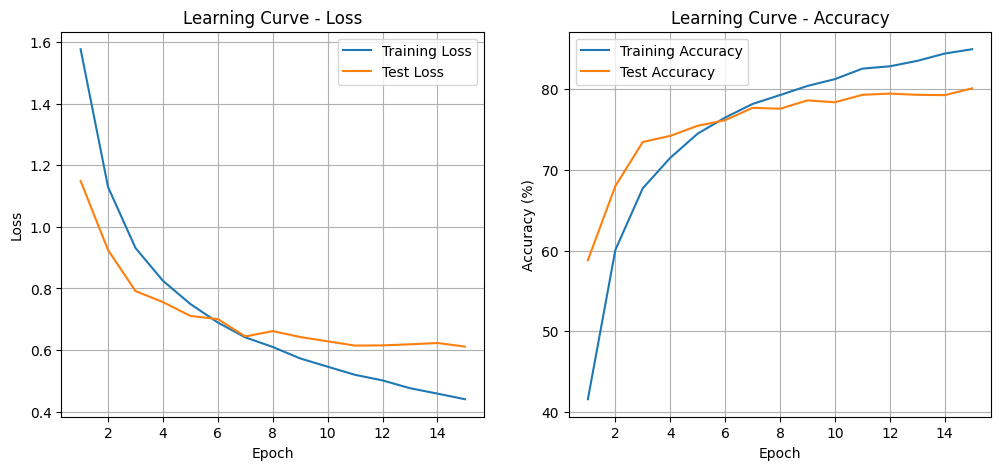

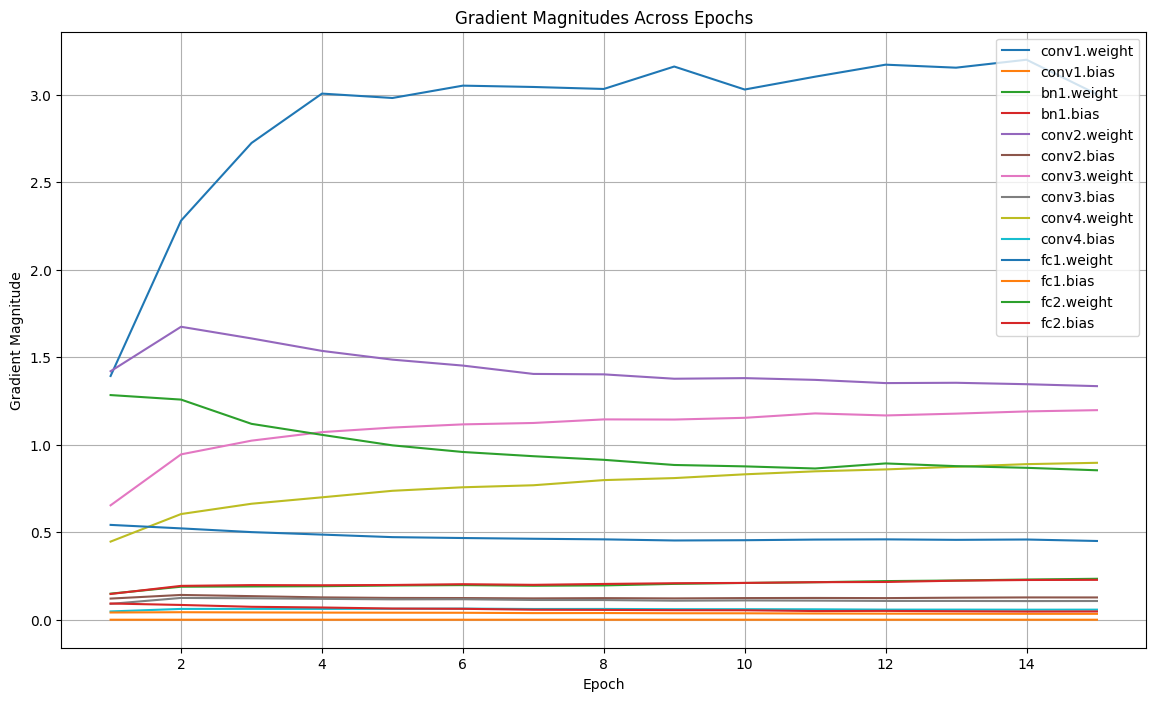

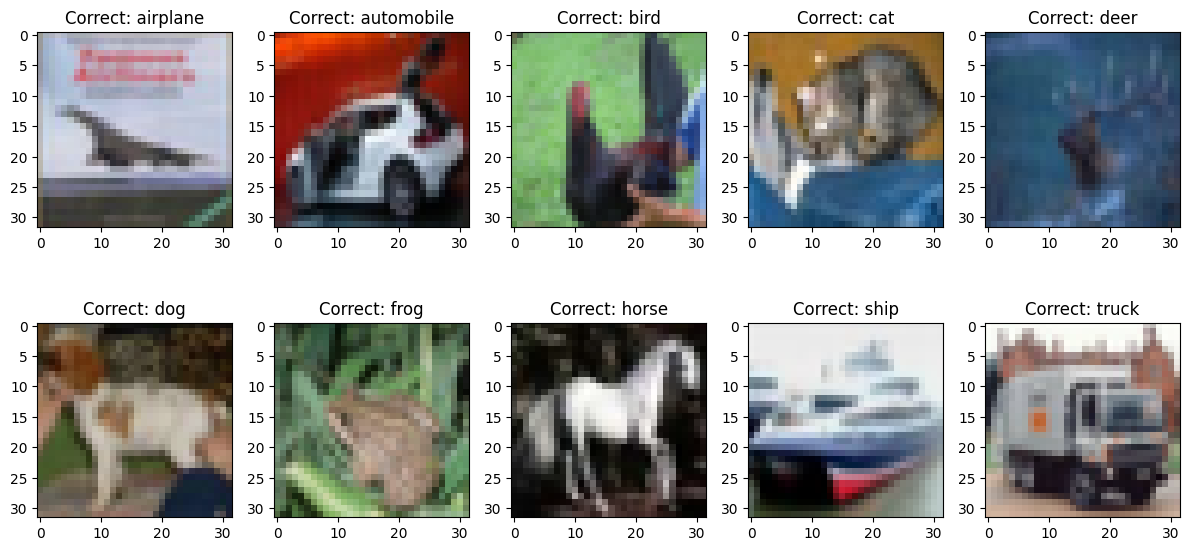

In [10]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Training Accuracy')
plt.plot(epochs, test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# Plot gradient magnitudes
plt.figure(figsize=(14, 8))

for layer_name, gradients in all_gradients.items():
    plt.plot(
        epochs,
        gradients,
        label=layer_name
    )

plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.title('Gradient Magnitudes Across Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Plot one correctly classified image from each class
def show_correct_examples_per_class(model, loader, classes):
    model.eval()

    correct_examples = {}

    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_device = labels.to(device)

            outputs = model(images_device)

            _, predicted = outputs.max(1)

            for i in range(images.size(0)):
                true_label = labels_device[i].item()
                pred_label = predicted[i].item()

                if true_label == pred_label and true_label not in correct_examples:
                    correct_examples[true_label] = images[i]

                if len(correct_examples) == 10:
                    break

            if len(correct_examples) == 10:
                break

    fig, axes = plt.subplots(2, 5, figsize=(12, 6))

    for class_idx, ax in enumerate(axes.flat):
        if class_idx in correct_examples:
            img = correct_examples[class_idx] / 2 + 0.5
            img = img.permute(1, 2, 0)

            ax.imshow(img)
            ax.set_title(f"Correct: {classes[class_idx]}")
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

show_correct_examples_per_class(
    model,
    test_loader,
    classes
)